In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import FuncFormatter

csv = pd.read_csv('airlines_flights_data.csv')

#Questions to answer:
'''
Q.1. What are the airlines in the dataset, accompanied by their frequencies? ✅

Q.2. Show Bar Graphs representing the Departure Time & Arrival Time. ✅

Q.3. Show Bar Graphs representing the Source City & Destination City. ✅

Q.4. Does price varies with airlines ? ✅

Q.5. Does ticket price change based on the departure time and arrival time? ✅

Q.6. How the price changes with change in Source and Destination? ✅

Q.7. How is the price affected when tickets are bought in just 1 or 2 days before departure? ✅

Q.8. How does the ticket price vary between Economy and Business class? ✅

Q.9. What will be the Average Price of Vistara airline for a flight from Delhi to Hyderabad in Business Class ? ✅  
'''

'\nQ.1. What are the airlines in the dataset, accompanied by their frequencies? ✅\n\nQ.2. Show Bar Graphs representing the Departure Time & Arrival Time. ✅\n\nQ.3. Show Bar Graphs representing the Source City & Destination City. ✅\n\nQ.4. Does price varies with airlines ? ✅\n\nQ.5. Does ticket price change based on the departure time and arrival time? ✅\n\nQ.6. How the price changes with change in Source and Destination? ✅\n\nQ.7. How is the price affected when tickets are bought in just 1 or 2 days before departure? ✅\n\nQ.8. How does the ticket price vary between Economy and Business class? ✅\n\nQ.9. What will be the Average Price of Vistara airline for a flight from Delhi to Hyderabad in Business Class ? ✅  \n'

In [3]:
#removing unnecessary column
csv.drop(columns='index', inplace=True)

#changing duration format to more readble format
csv['duration'] = pd.to_timedelta(csv['duration'], unit='h')
func = lambda x: f'{int(x.total_seconds()//3600)}h {int((x.total_seconds()%3600)//60):02d}m'
csv['duration'] = csv['duration'].apply(func)

#formatting stops column - you can also use apply with a lambda function
mapping = {"zero" : "0", "one" : "1", "two_or_more" : "2+"}
csv['stops'] = csv['stops'].map(mapping)

In [4]:
csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   airline           300153 non-null  object
 1   flight            300153 non-null  object
 2   source_city       300153 non-null  object
 3   departure_time    300153 non-null  object
 4   stops             300153 non-null  object
 5   arrival_time      300153 non-null  object
 6   destination_city  300153 non-null  object
 7   class             300153 non-null  object
 8   duration          300153 non-null  object
 9   days_left         300153 non-null  int64 
 10  price             300153 non-null  int64 
dtypes: int64(2), object(9)
memory usage: 25.2+ MB


In [5]:
csv.sample(5)

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
216507,Vistara,UK-985,Delhi,Evening,1,Evening,Kolkata,Business,21h 00m,11,73369
180927,Vistara,UK-822,Chennai,Morning,1,Evening,Delhi,Economy,7h 10m,6,11868
104649,SpiceJet,SG-401,Bangalore,Early_Morning,1,Morning,Kolkata,Economy,4h 49m,16,3916
41081,Air_India,AI-542,Delhi,Morning,1,Early_Morning,Chennai,Economy,22h 15m,38,3306
142293,GO_FIRST,G8-519,Kolkata,Evening,1,Late_Night,Bangalore,Economy,7h 00m,48,6109


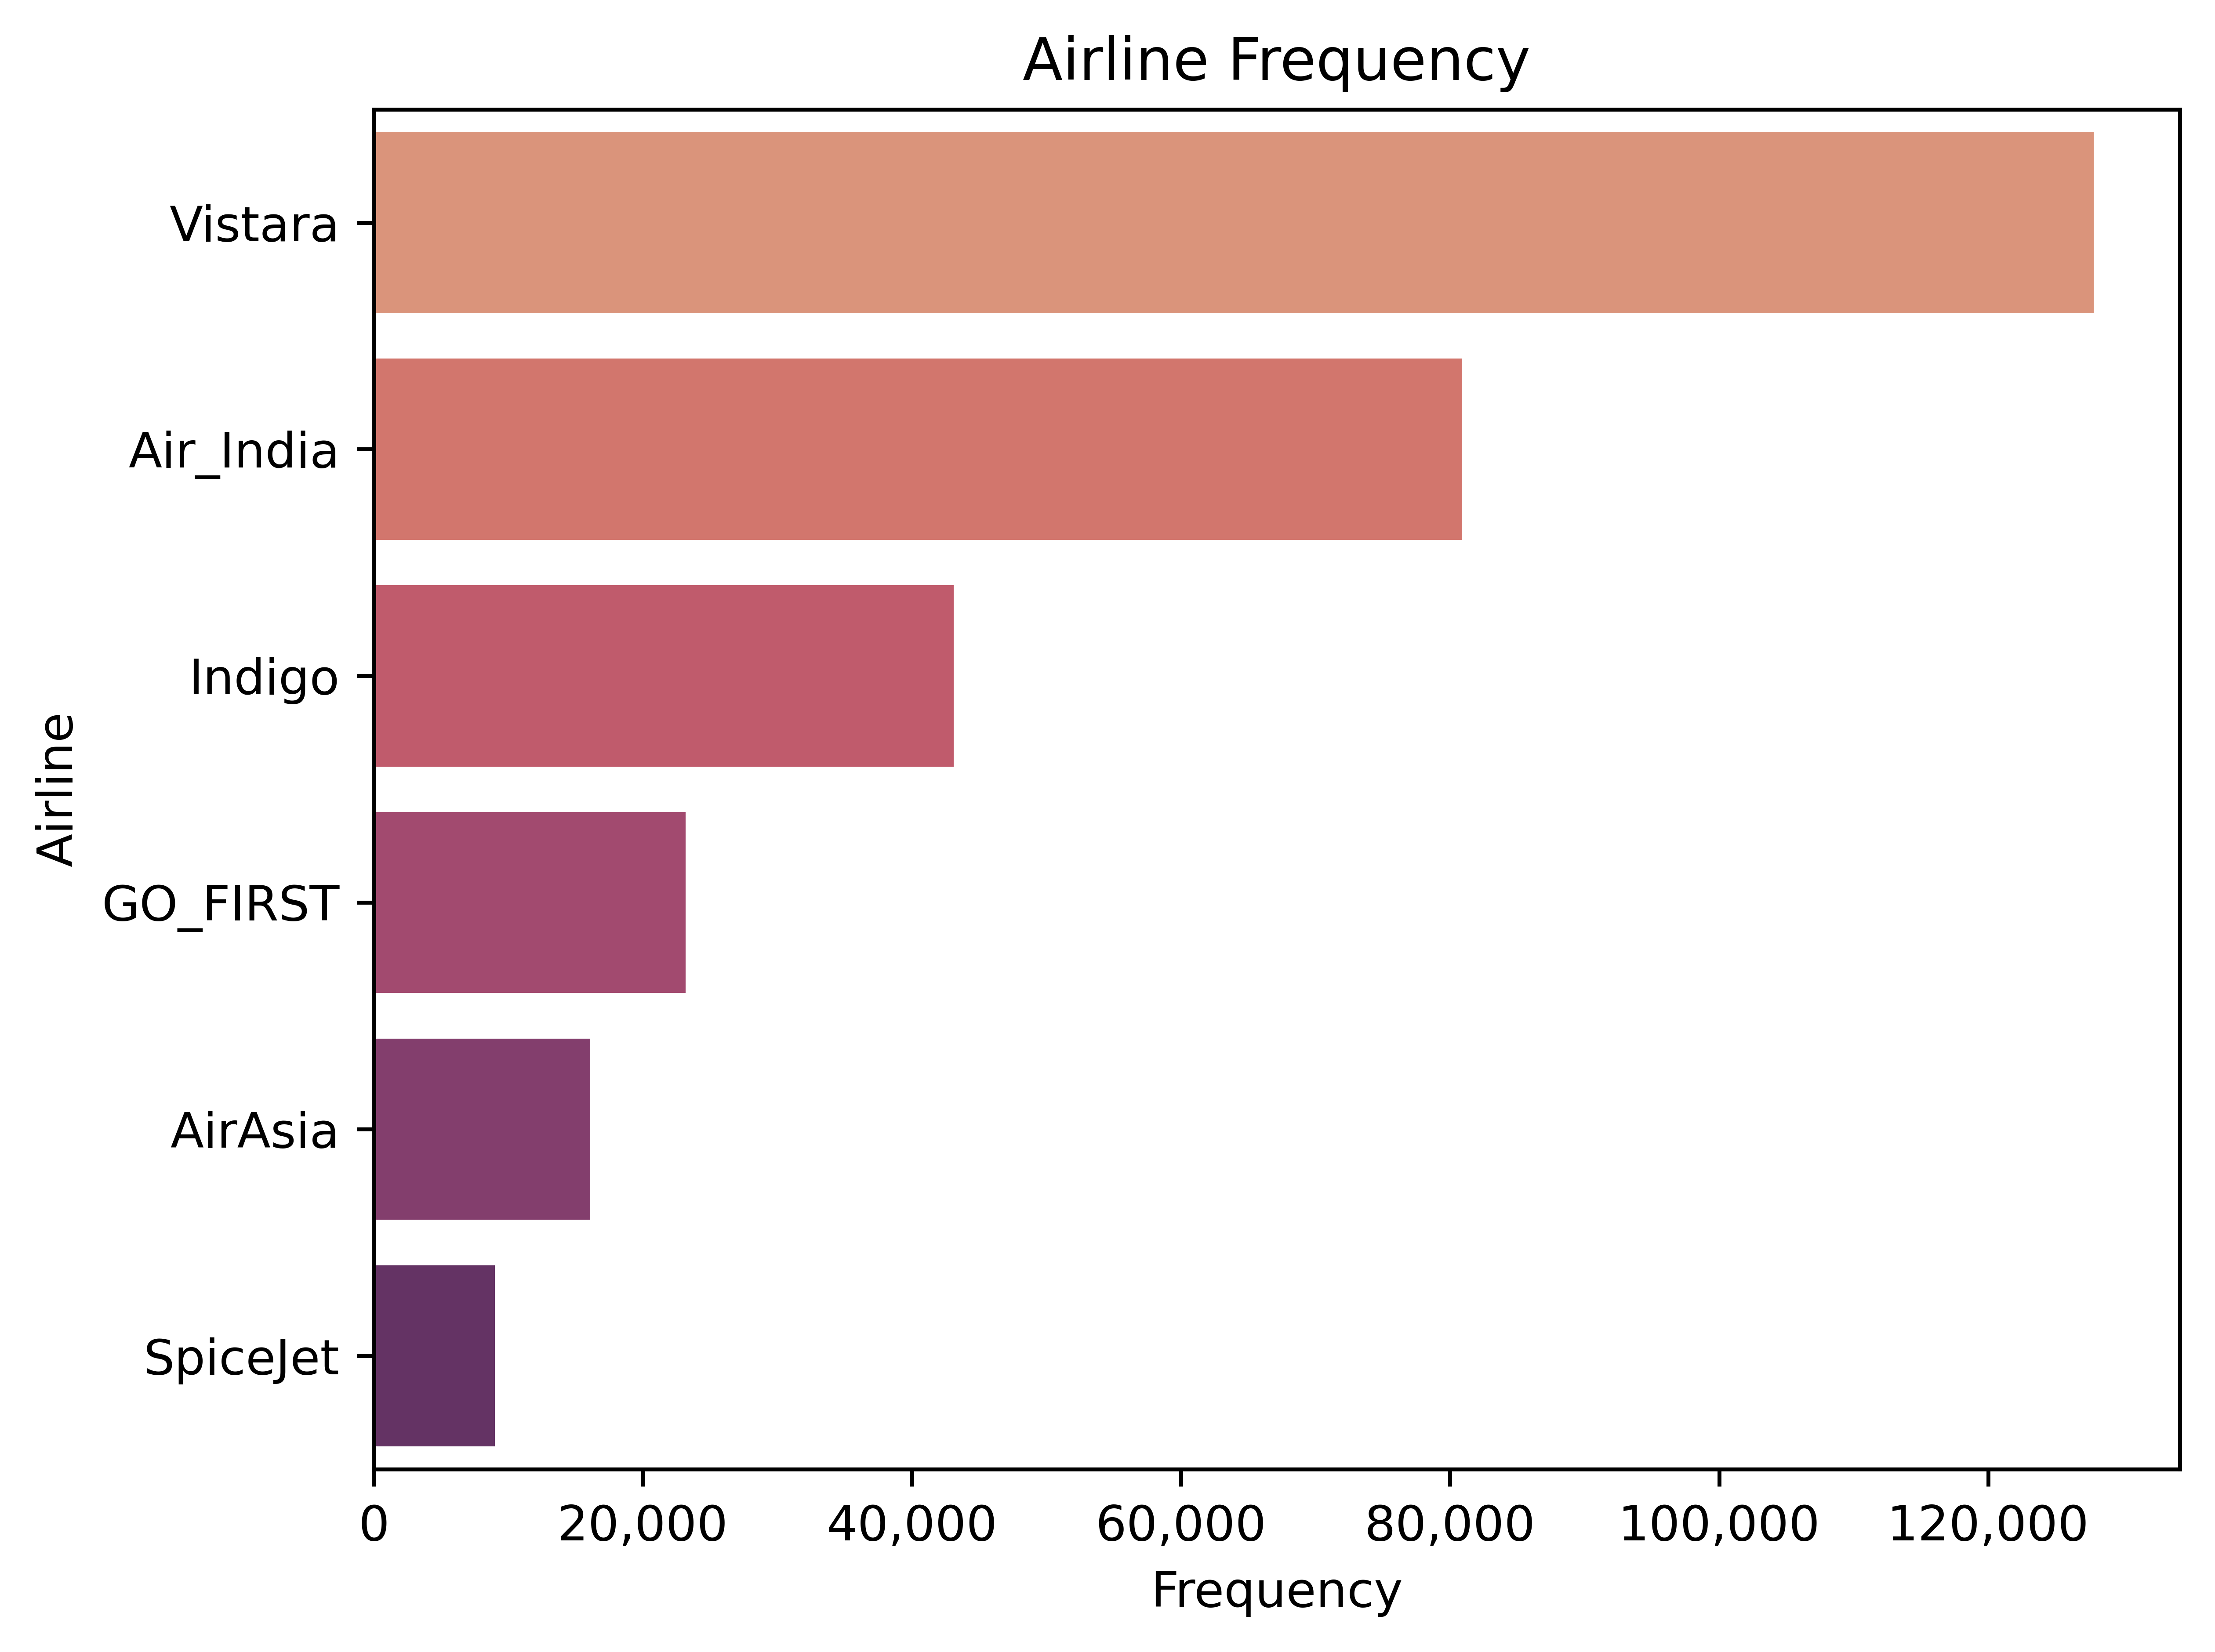

In [6]:
#Q.1. What are the airlines in the dataset, accompanied by their frequencies?

csv_plot = csv[['airline']].value_counts().reset_index()
sns.barplot(data=csv_plot, x=csv_plot['count'], y=csv_plot['airline'], hue=csv_plot['airline'], palette='flare')
plt.title('Airline Frequency')
plt.xlabel('Frequency')
plt.ylabel('Airline')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

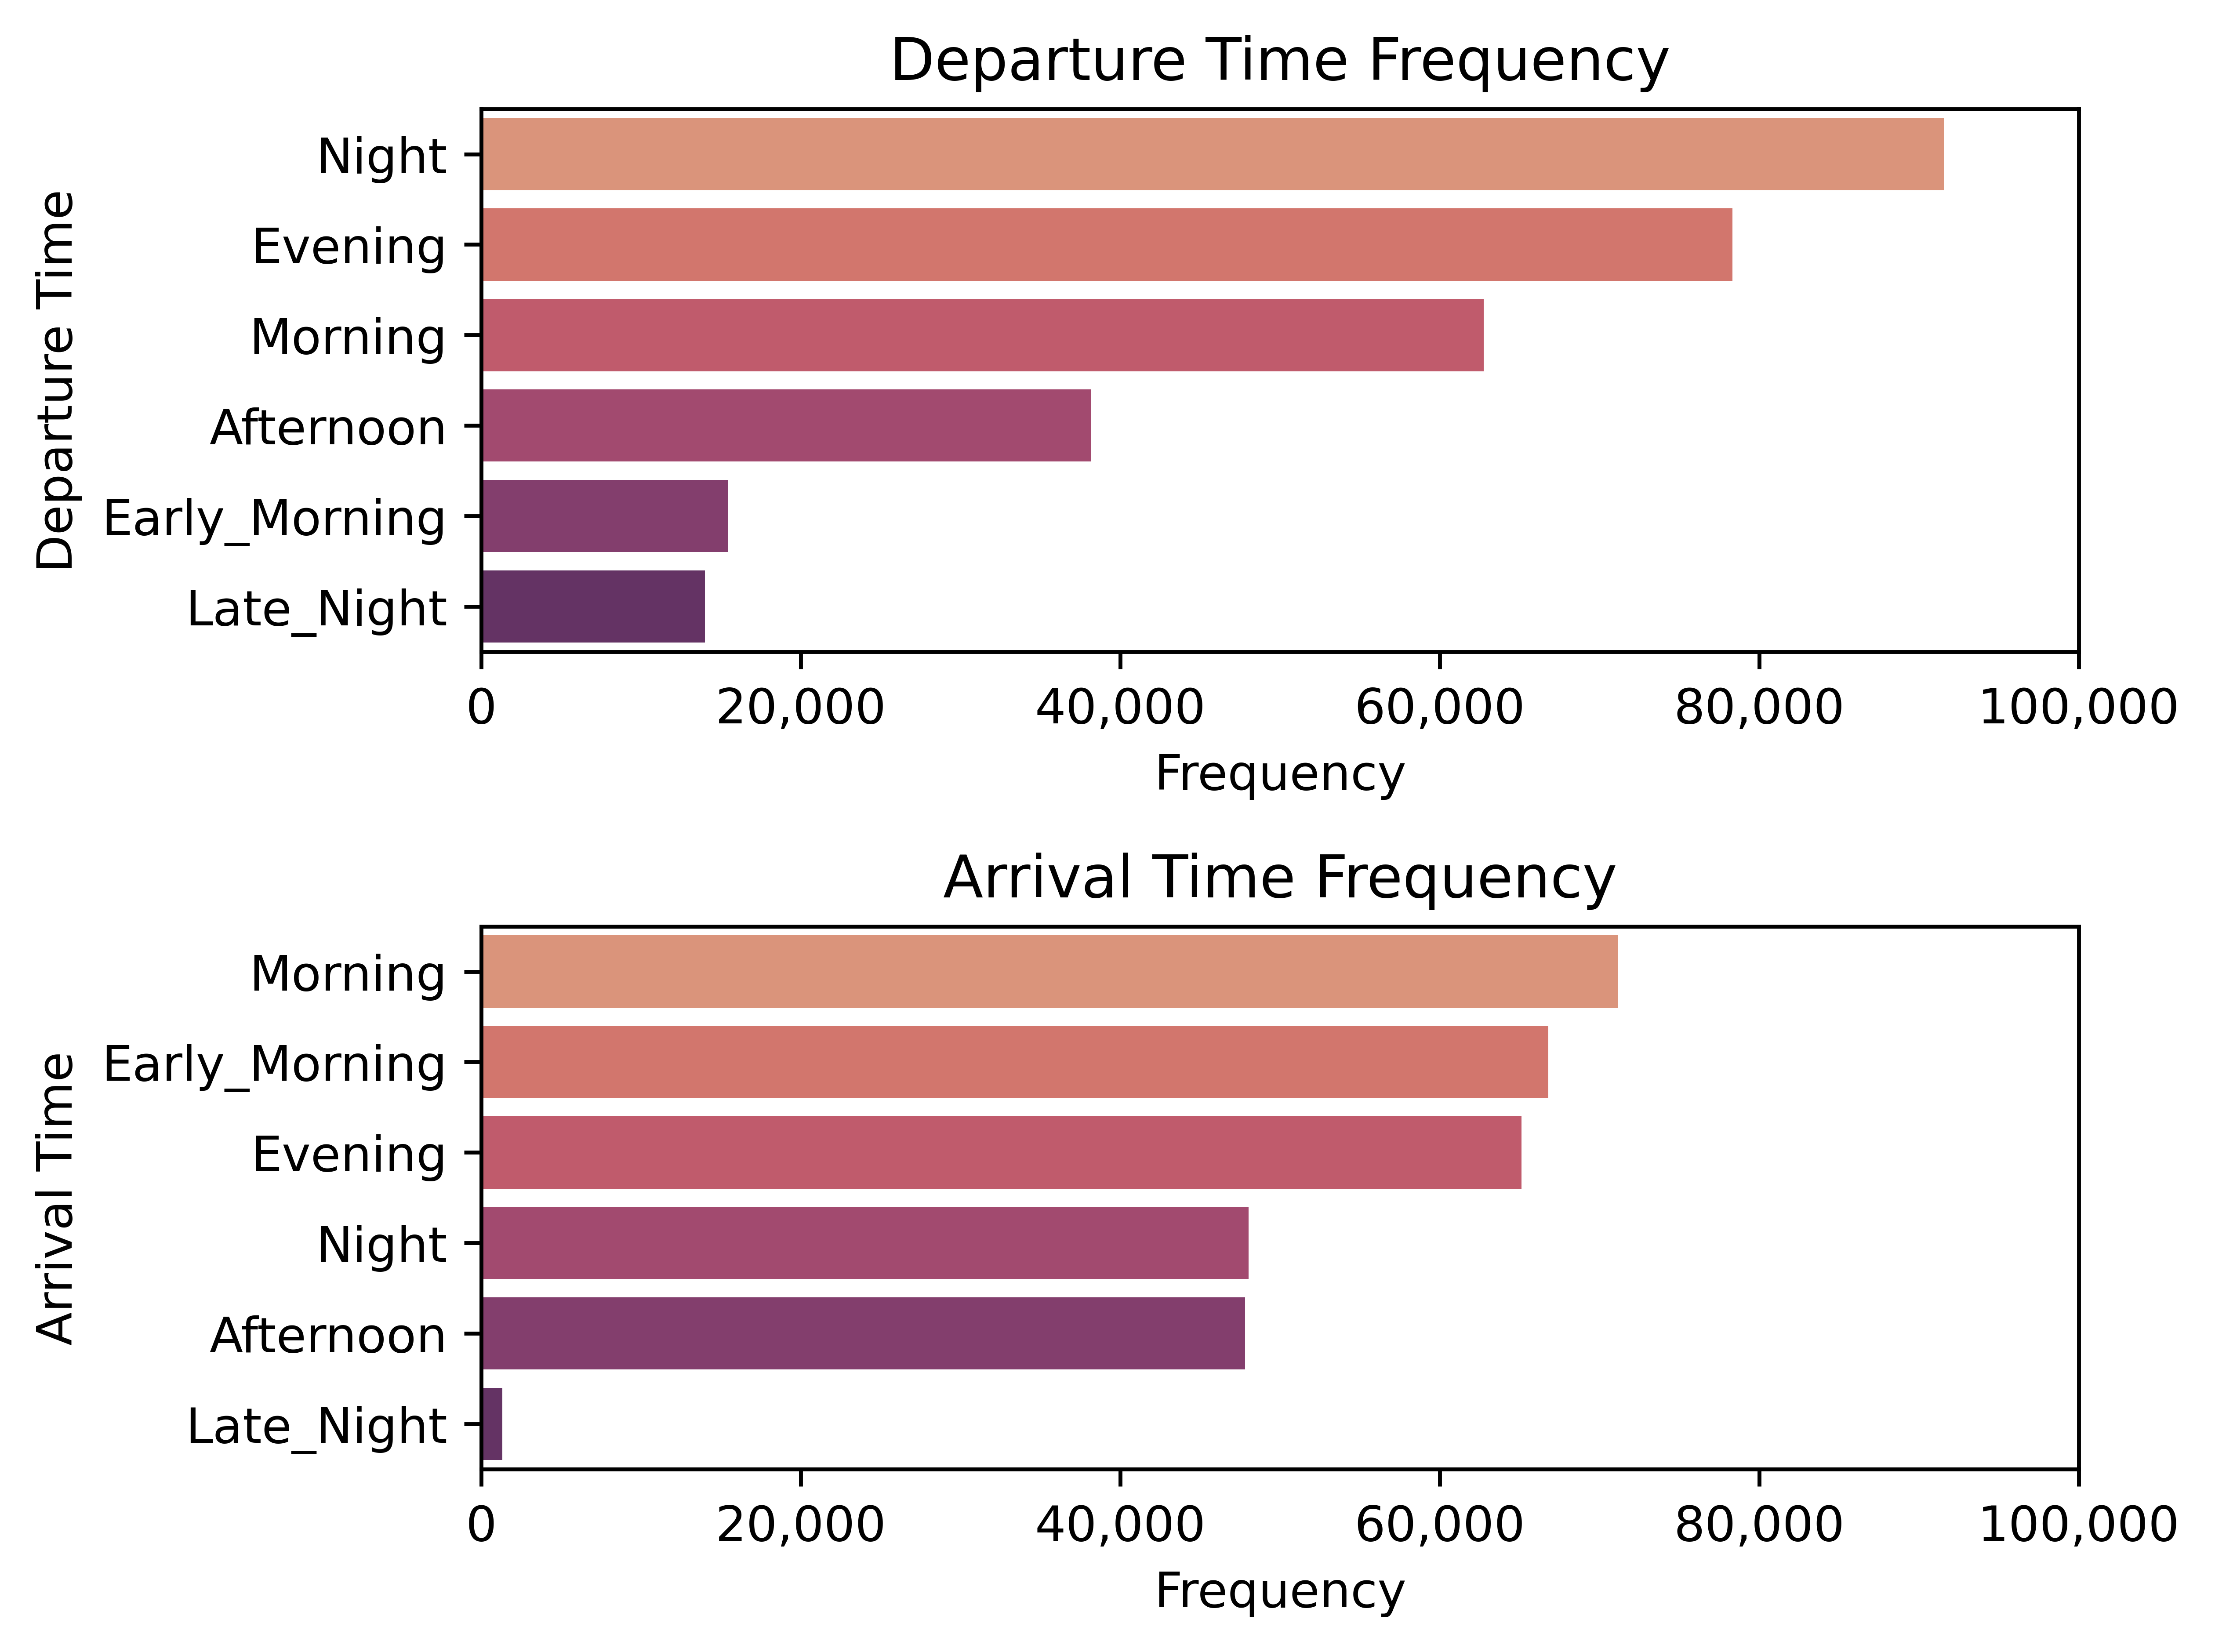

In [7]:
#Q.2. Show Bar Graphs representing the Departure Time & Arrival Time.
fig, ax = plt.subplots(2,1)
csv_plot = [csv[['departure_time']].value_counts().reset_index(), csv[['arrival_time']].value_counts().reset_index()]
sns.barplot(data=csv_plot[0], x=csv_plot[0]['count'], y=csv_plot[0]['departure_time'], hue=csv_plot[0]['departure_time'], palette='flare', ax=ax[1])
sns.barplot(data=csv_plot[1], x=csv_plot[1]['count'], y=csv_plot[1]['arrival_time'], hue=csv_plot[1]['arrival_time'], palette='flare', ax=ax[0])
ax[0].set_title('Departure Time Frequency')
ax[0].set_xlabel('Frequency')
ax[0].set_ylabel('Departure Time')
ax[1].set_title('Arrival Time Frequency')
ax[1].set_xlabel('Frequency')
ax[1].set_ylabel('Arrival Time')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax[0].figure.set_dpi(800)
ax[1].figure.set_dpi(800)
ax[0].set_xlim(0, 100_000)
ax[1].set_xlim(0, 100_000)
fig.tight_layout()
plt.show()

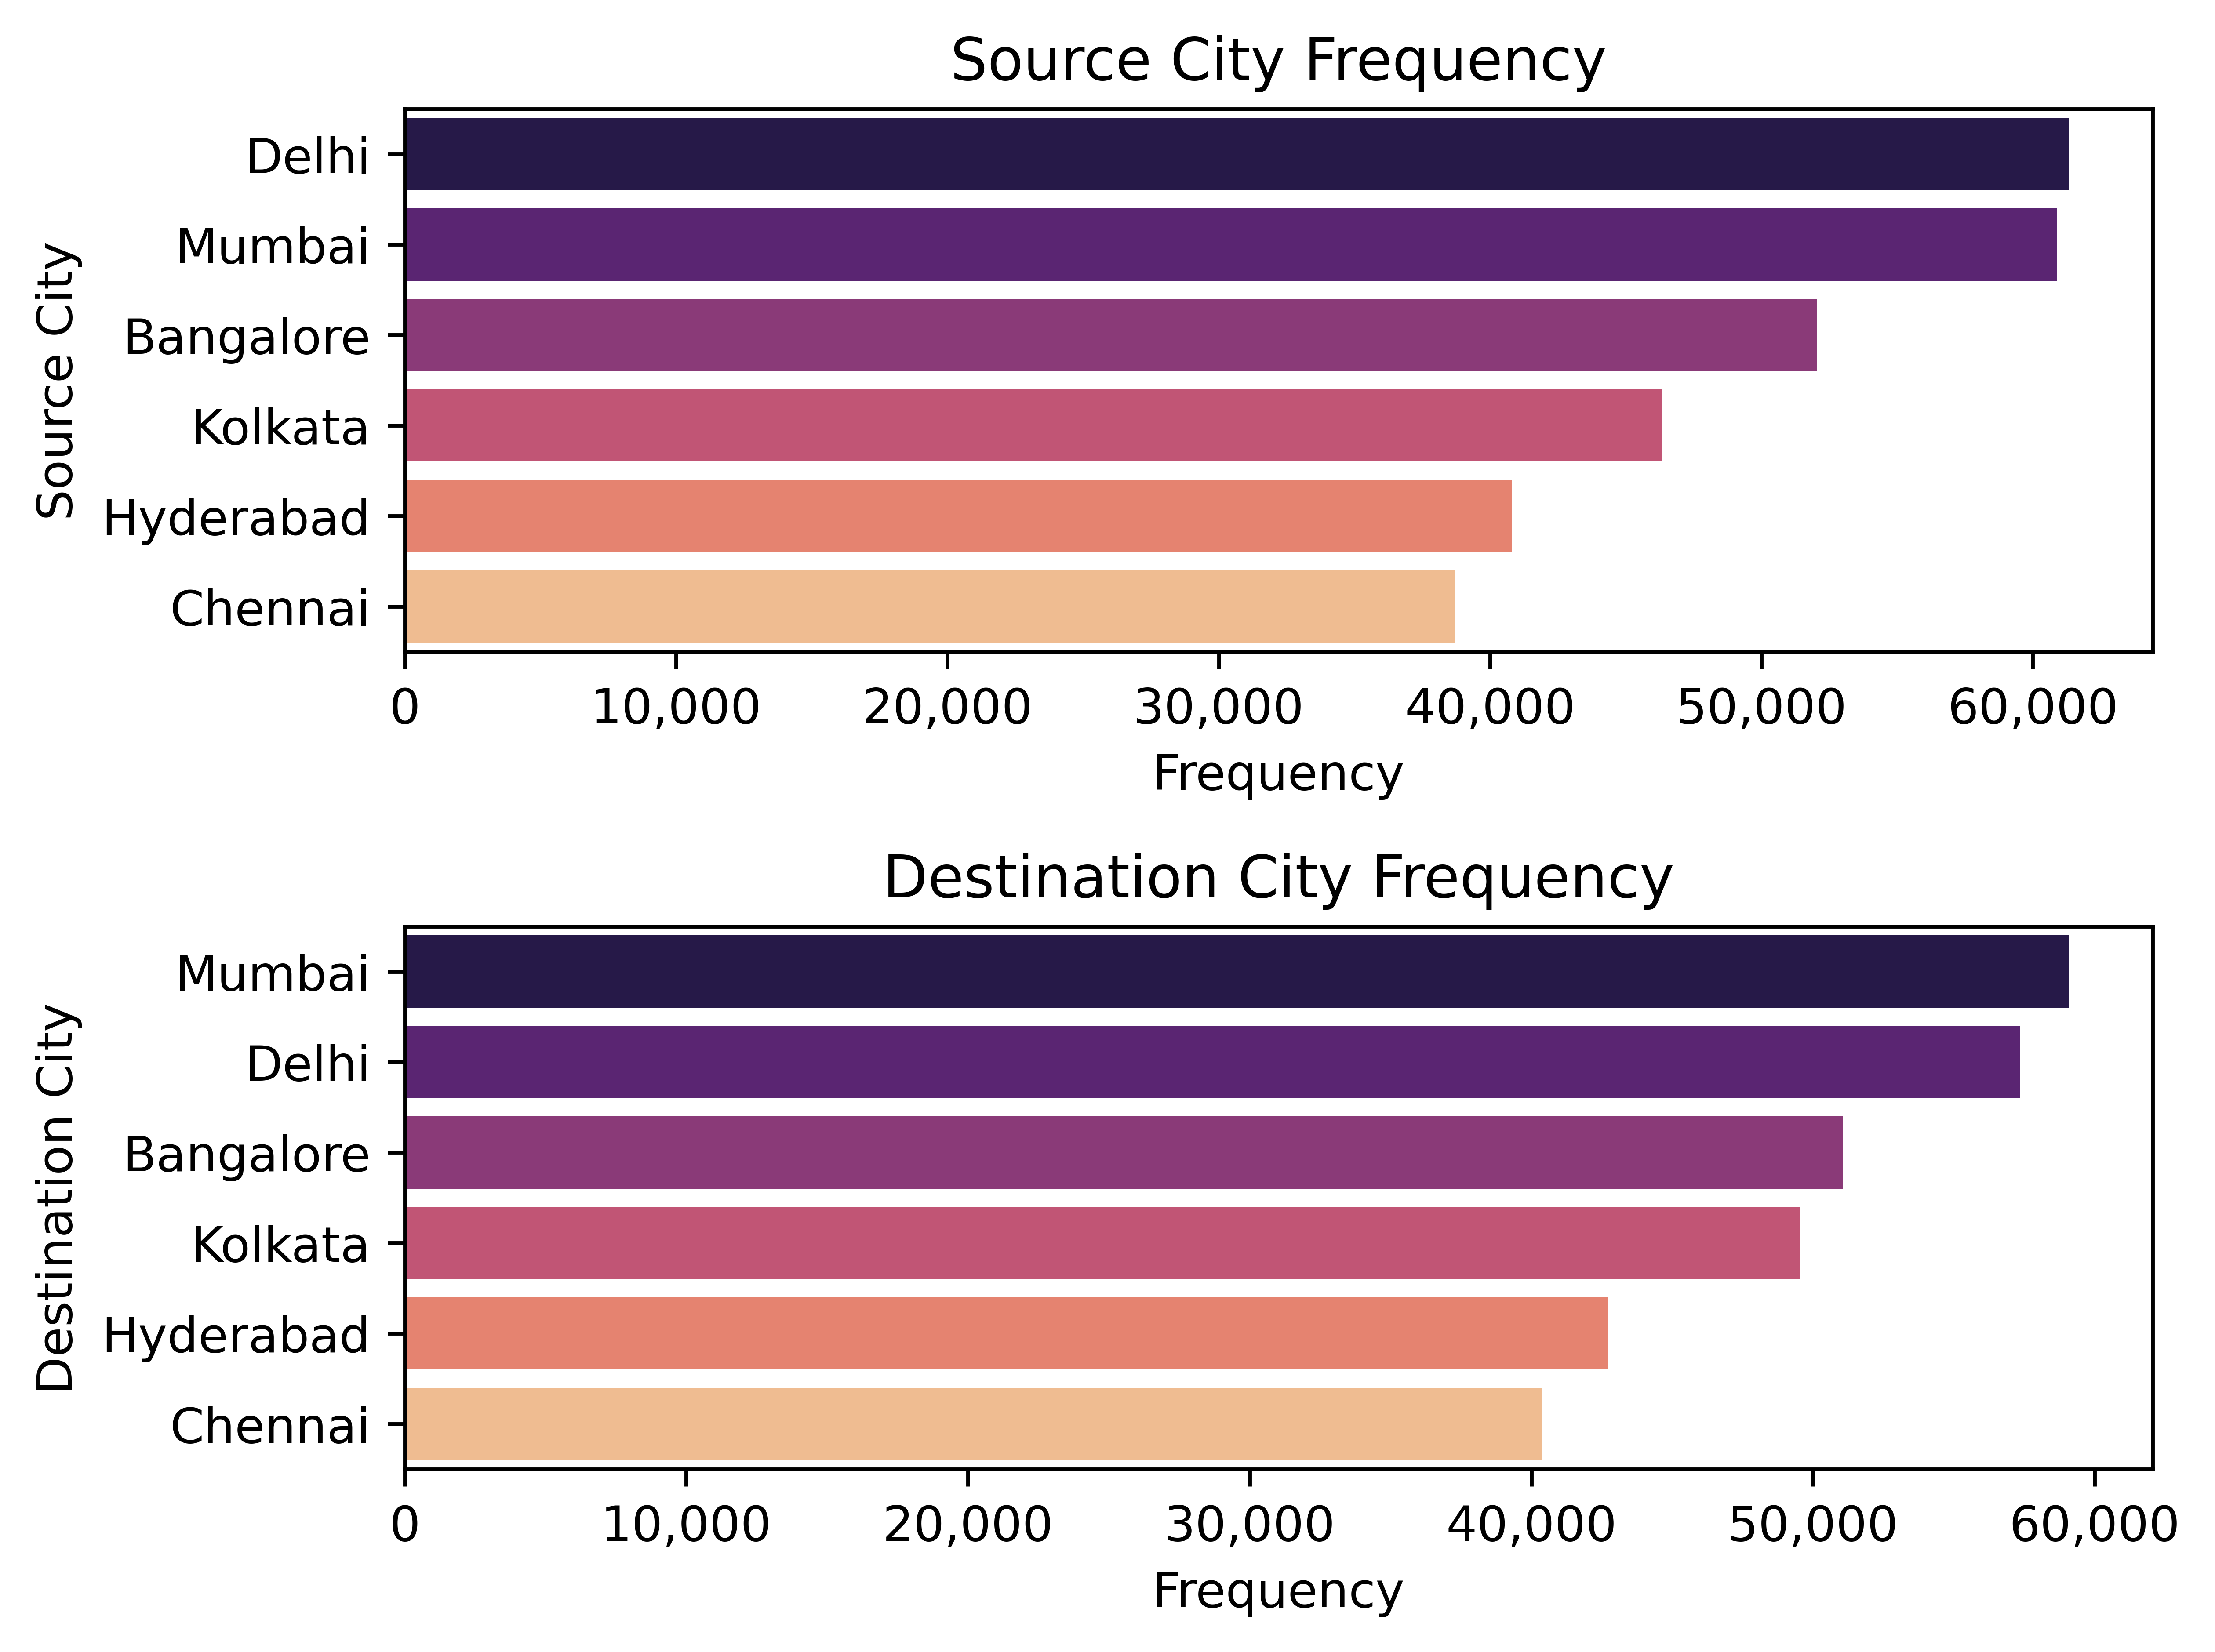

In [8]:
#Q.3. Show Bar Graphs representing the Source City & Destination City.
fig, ax = plt.subplots(2,1)
csv_plot = [csv[['source_city']].value_counts().reset_index(), csv[['destination_city']].value_counts().reset_index()]
sns.barplot(data=csv_plot[0], x=csv_plot[0]["count"], y=csv_plot[0]['source_city'], hue=csv_plot[0]['source_city'], palette='magma', ax=ax[0])
sns.barplot(data=csv_plot[1], x=csv_plot[1]["count"], y=csv_plot[1]['destination_city'], hue=csv_plot[1]['destination_city'], palette='magma', ax=ax[1])
ax[0].set_title('Source City Frequency')
ax[0].set_xlabel('Frequency')
ax[0].set_ylabel('Source City')
ax[1].set_title('Destination City Frequency')
ax[1].set_xlabel('Frequency')
ax[1].set_ylabel('Destination City')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax[0].figure.set_dpi(800)
ax[1].figure.set_dpi(800)
plt.tight_layout()
plt.show()

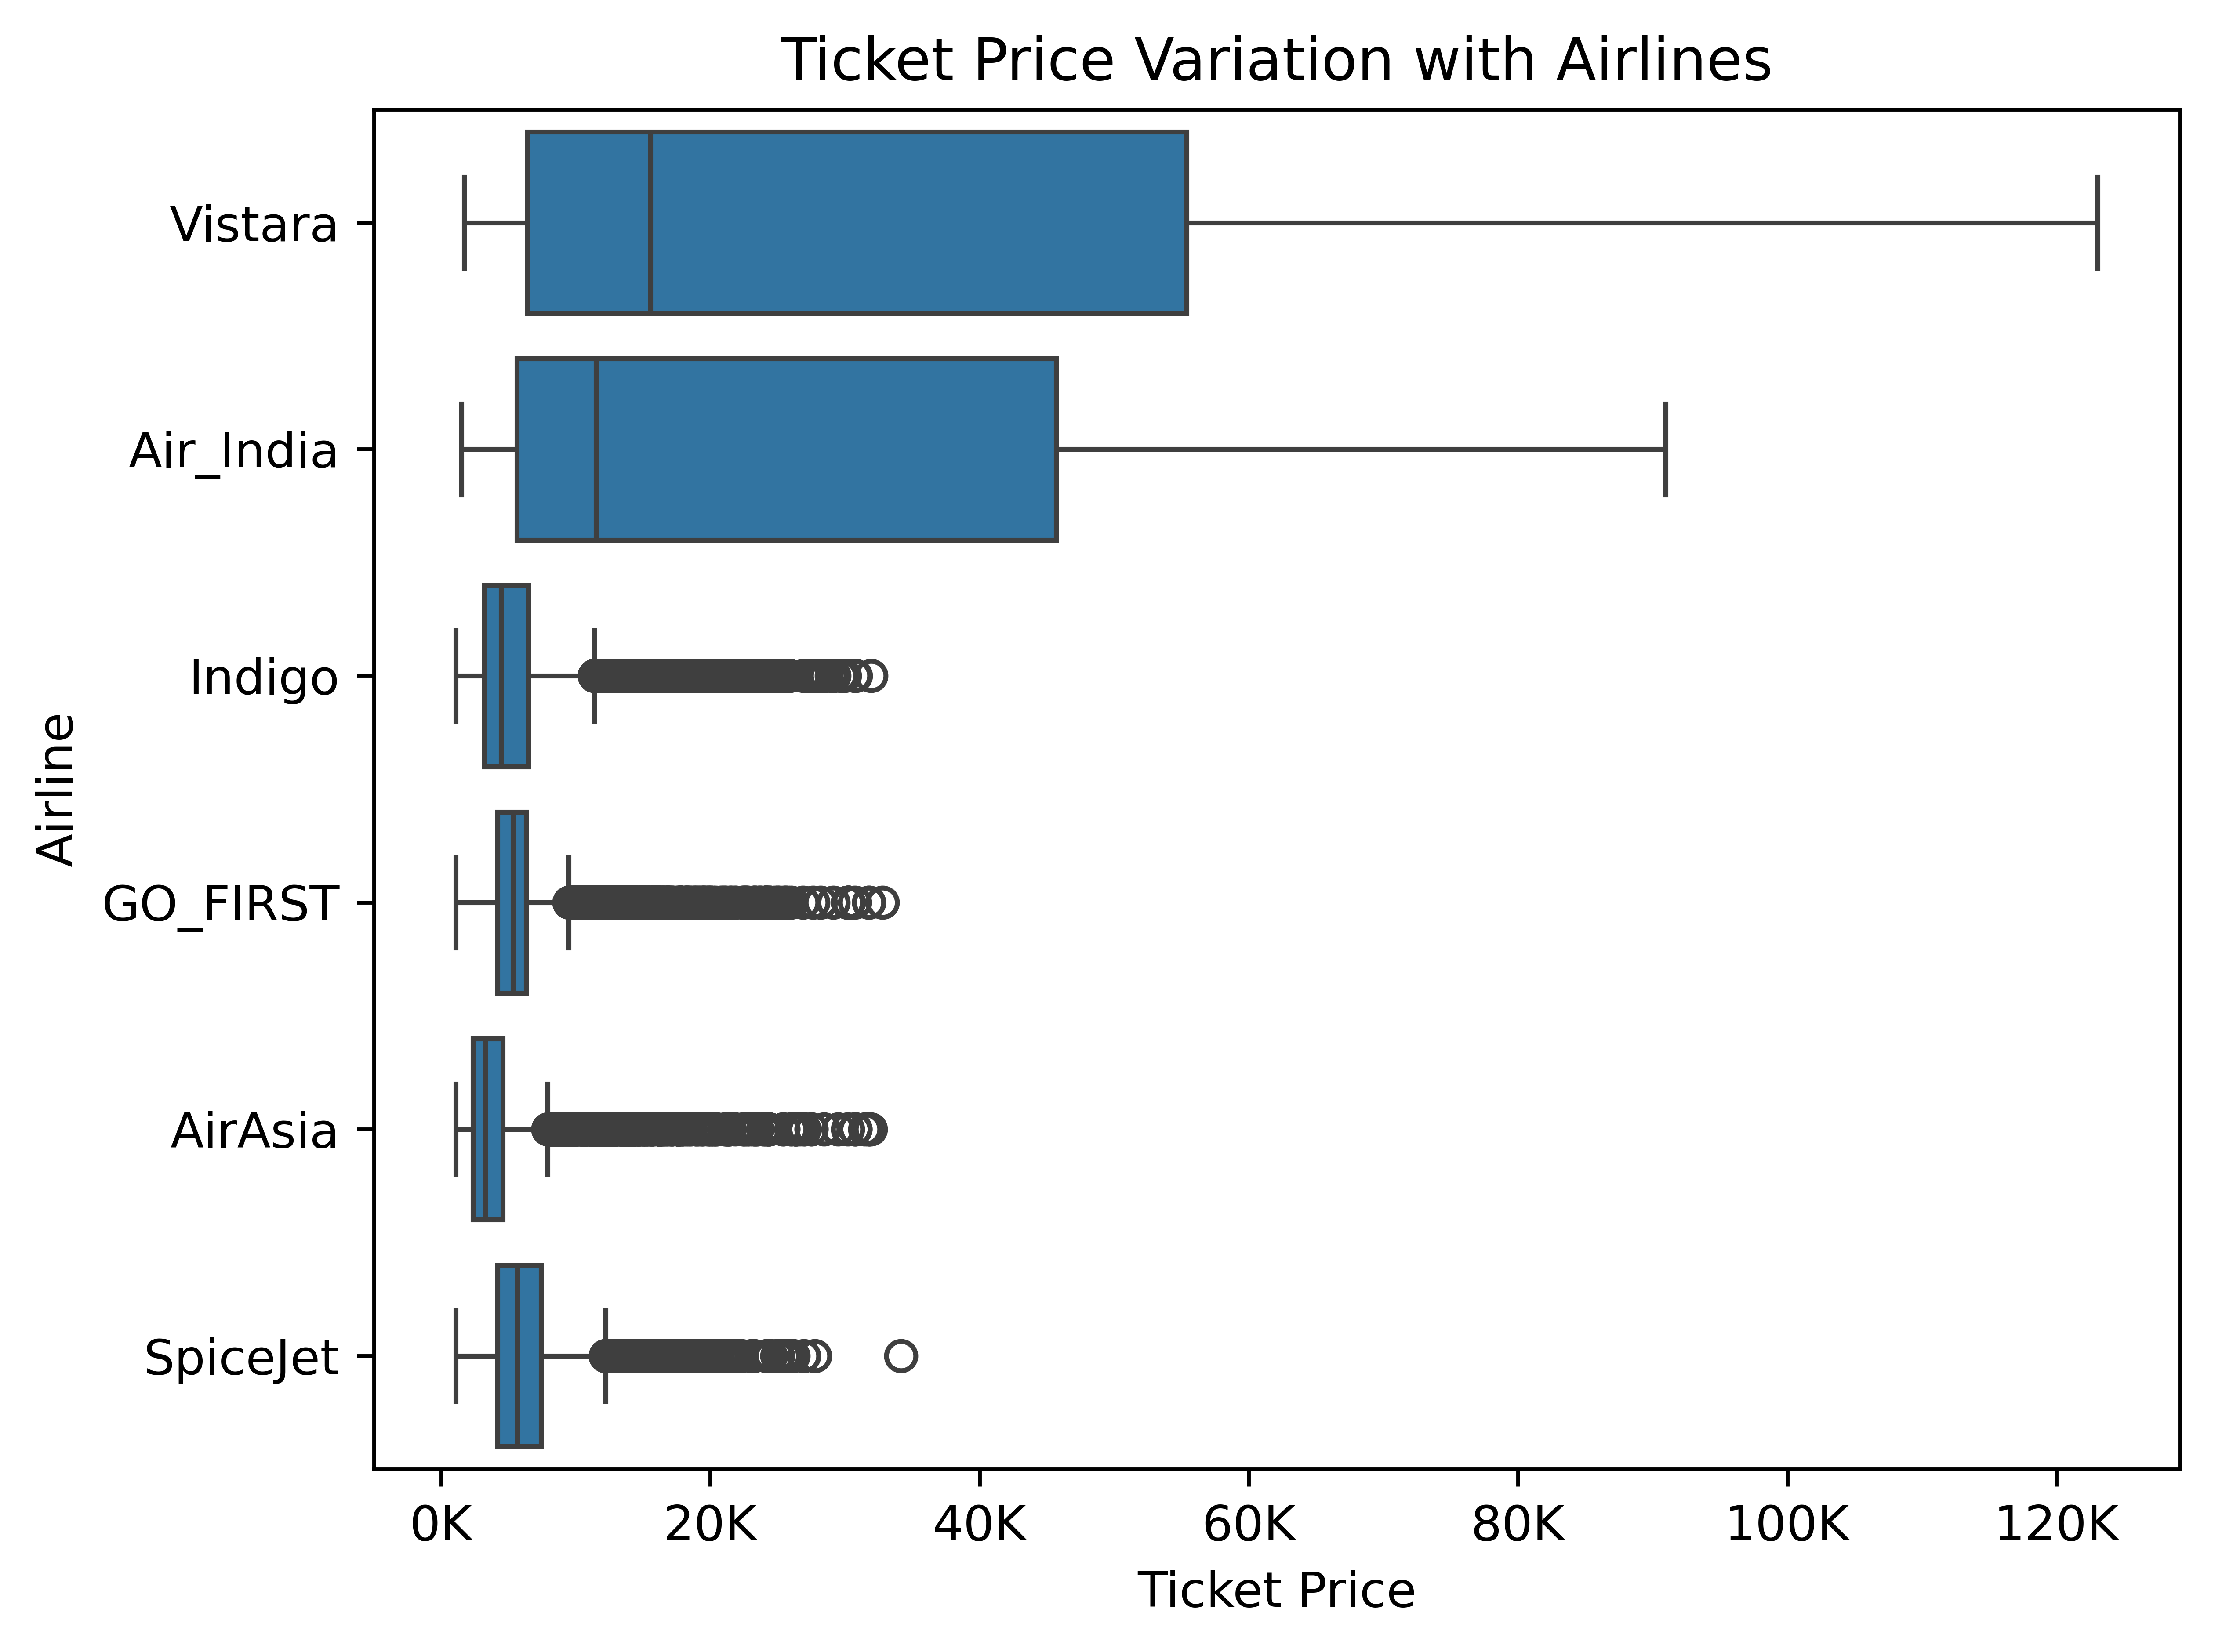

In [9]:
#Q.4. Does price varies with airlines ?
csv_plot = csv[['airline', 'price']].copy()
sns.boxplot(data=csv_plot, x='price', y='airline', order=csv_plot['airline'].value_counts().index)
plt.title('Ticket Price Variation with Airlines')
plt.xlabel('Ticket Price')
plt.ylabel('Airline')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

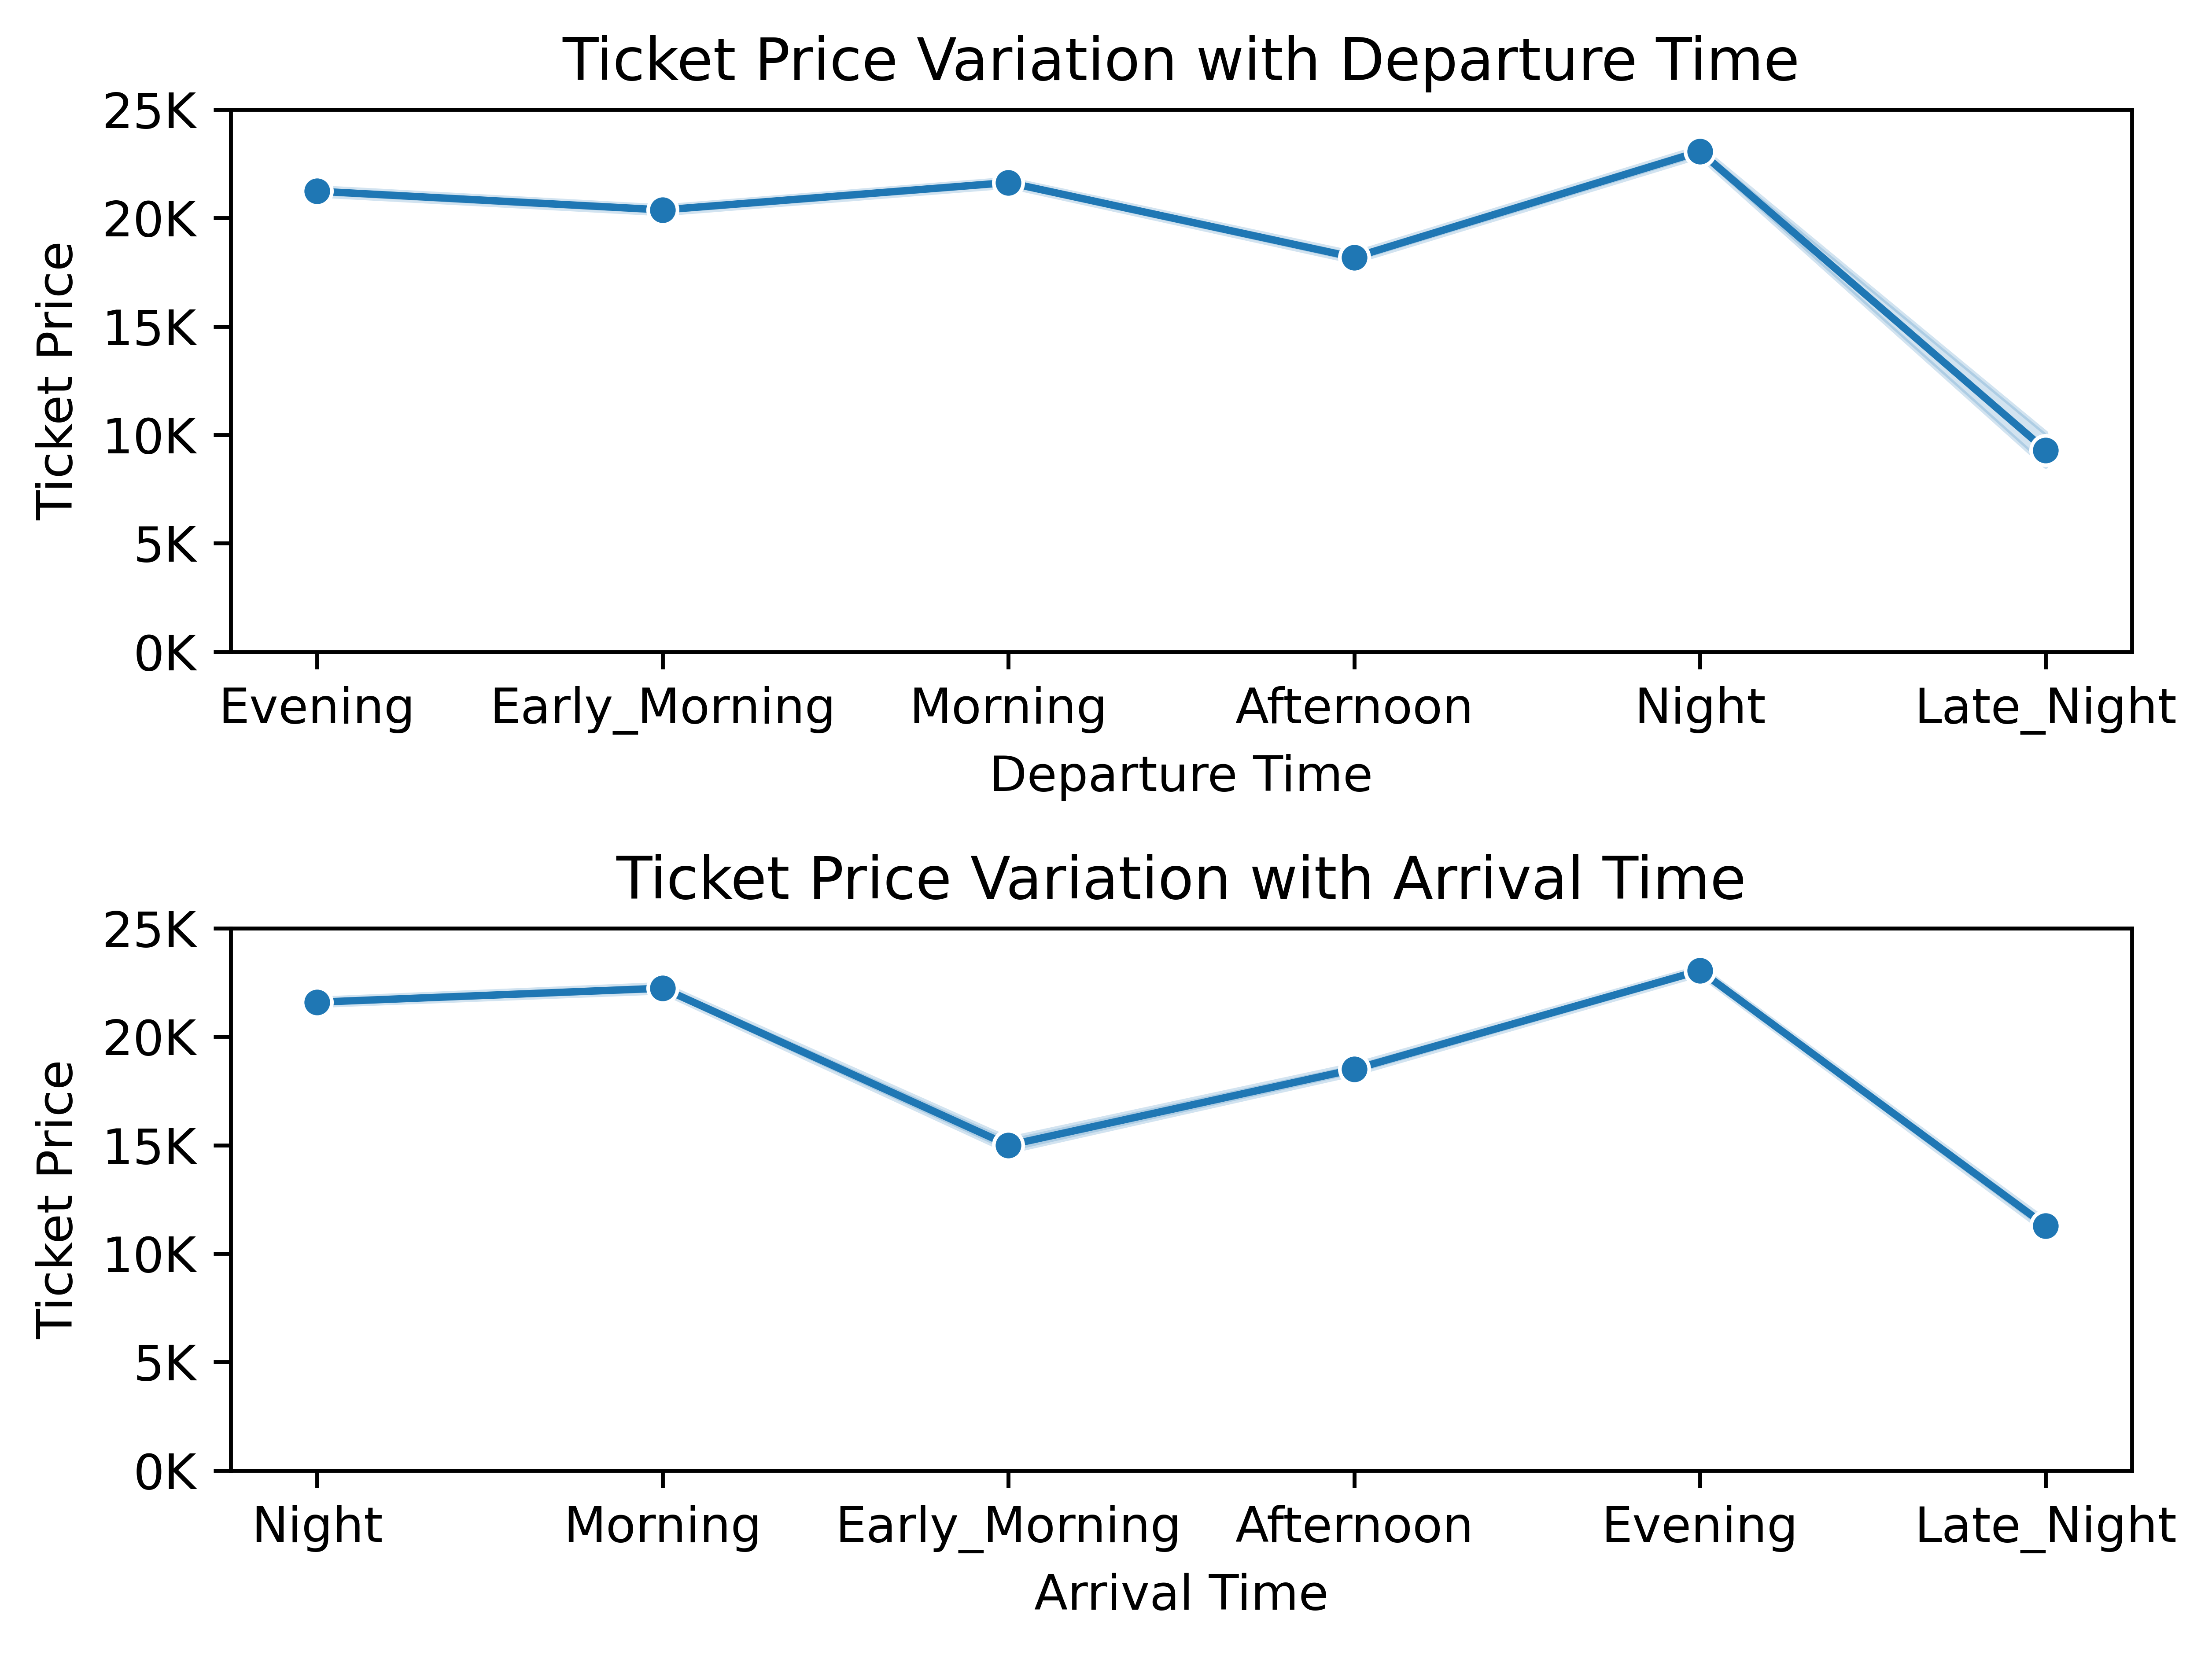

In [10]:
#Q.5. Does ticket price change based on the departure time and arrival time?
csv_plot = csv[['departure_time', 'arrival_time', 'price']].copy()
fig, ax = plt.subplots(2, 1)
sns.lineplot(data=csv_plot, x='departure_time', y='price', ax=ax[0], marker='o')
sns.lineplot(data=csv_plot, x='arrival_time', y='price', ax=ax[1], marker='o')
ax[0].set_title('Ticket Price Variation with Departure Time')
ax[0].set_xlabel('Departure Time')
ax[0].set_ylabel('Ticket Price')
ax[1].set_title('Ticket Price Variation with Arrival Time')
ax[1].set_xlabel('Arrival Time')
ax[1].set_ylabel('Ticket Price')
ax[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[0].figure.set_dpi(800)
ax[1].figure.set_dpi(800)
ax[0].set_ylim(0, 25000)
ax[1].set_ylim(0, 25000)
plt.tight_layout()
plt.show()

/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_4444/1988398859.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=csv_plot, x='price', y='source_city', order=ascending_order, palette='mako', ax=ax[0])
/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_4444/1988398859.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=csv_plot, x='price', y='destination_city', order=ascending_order, palette='mako', ax=ax[1])


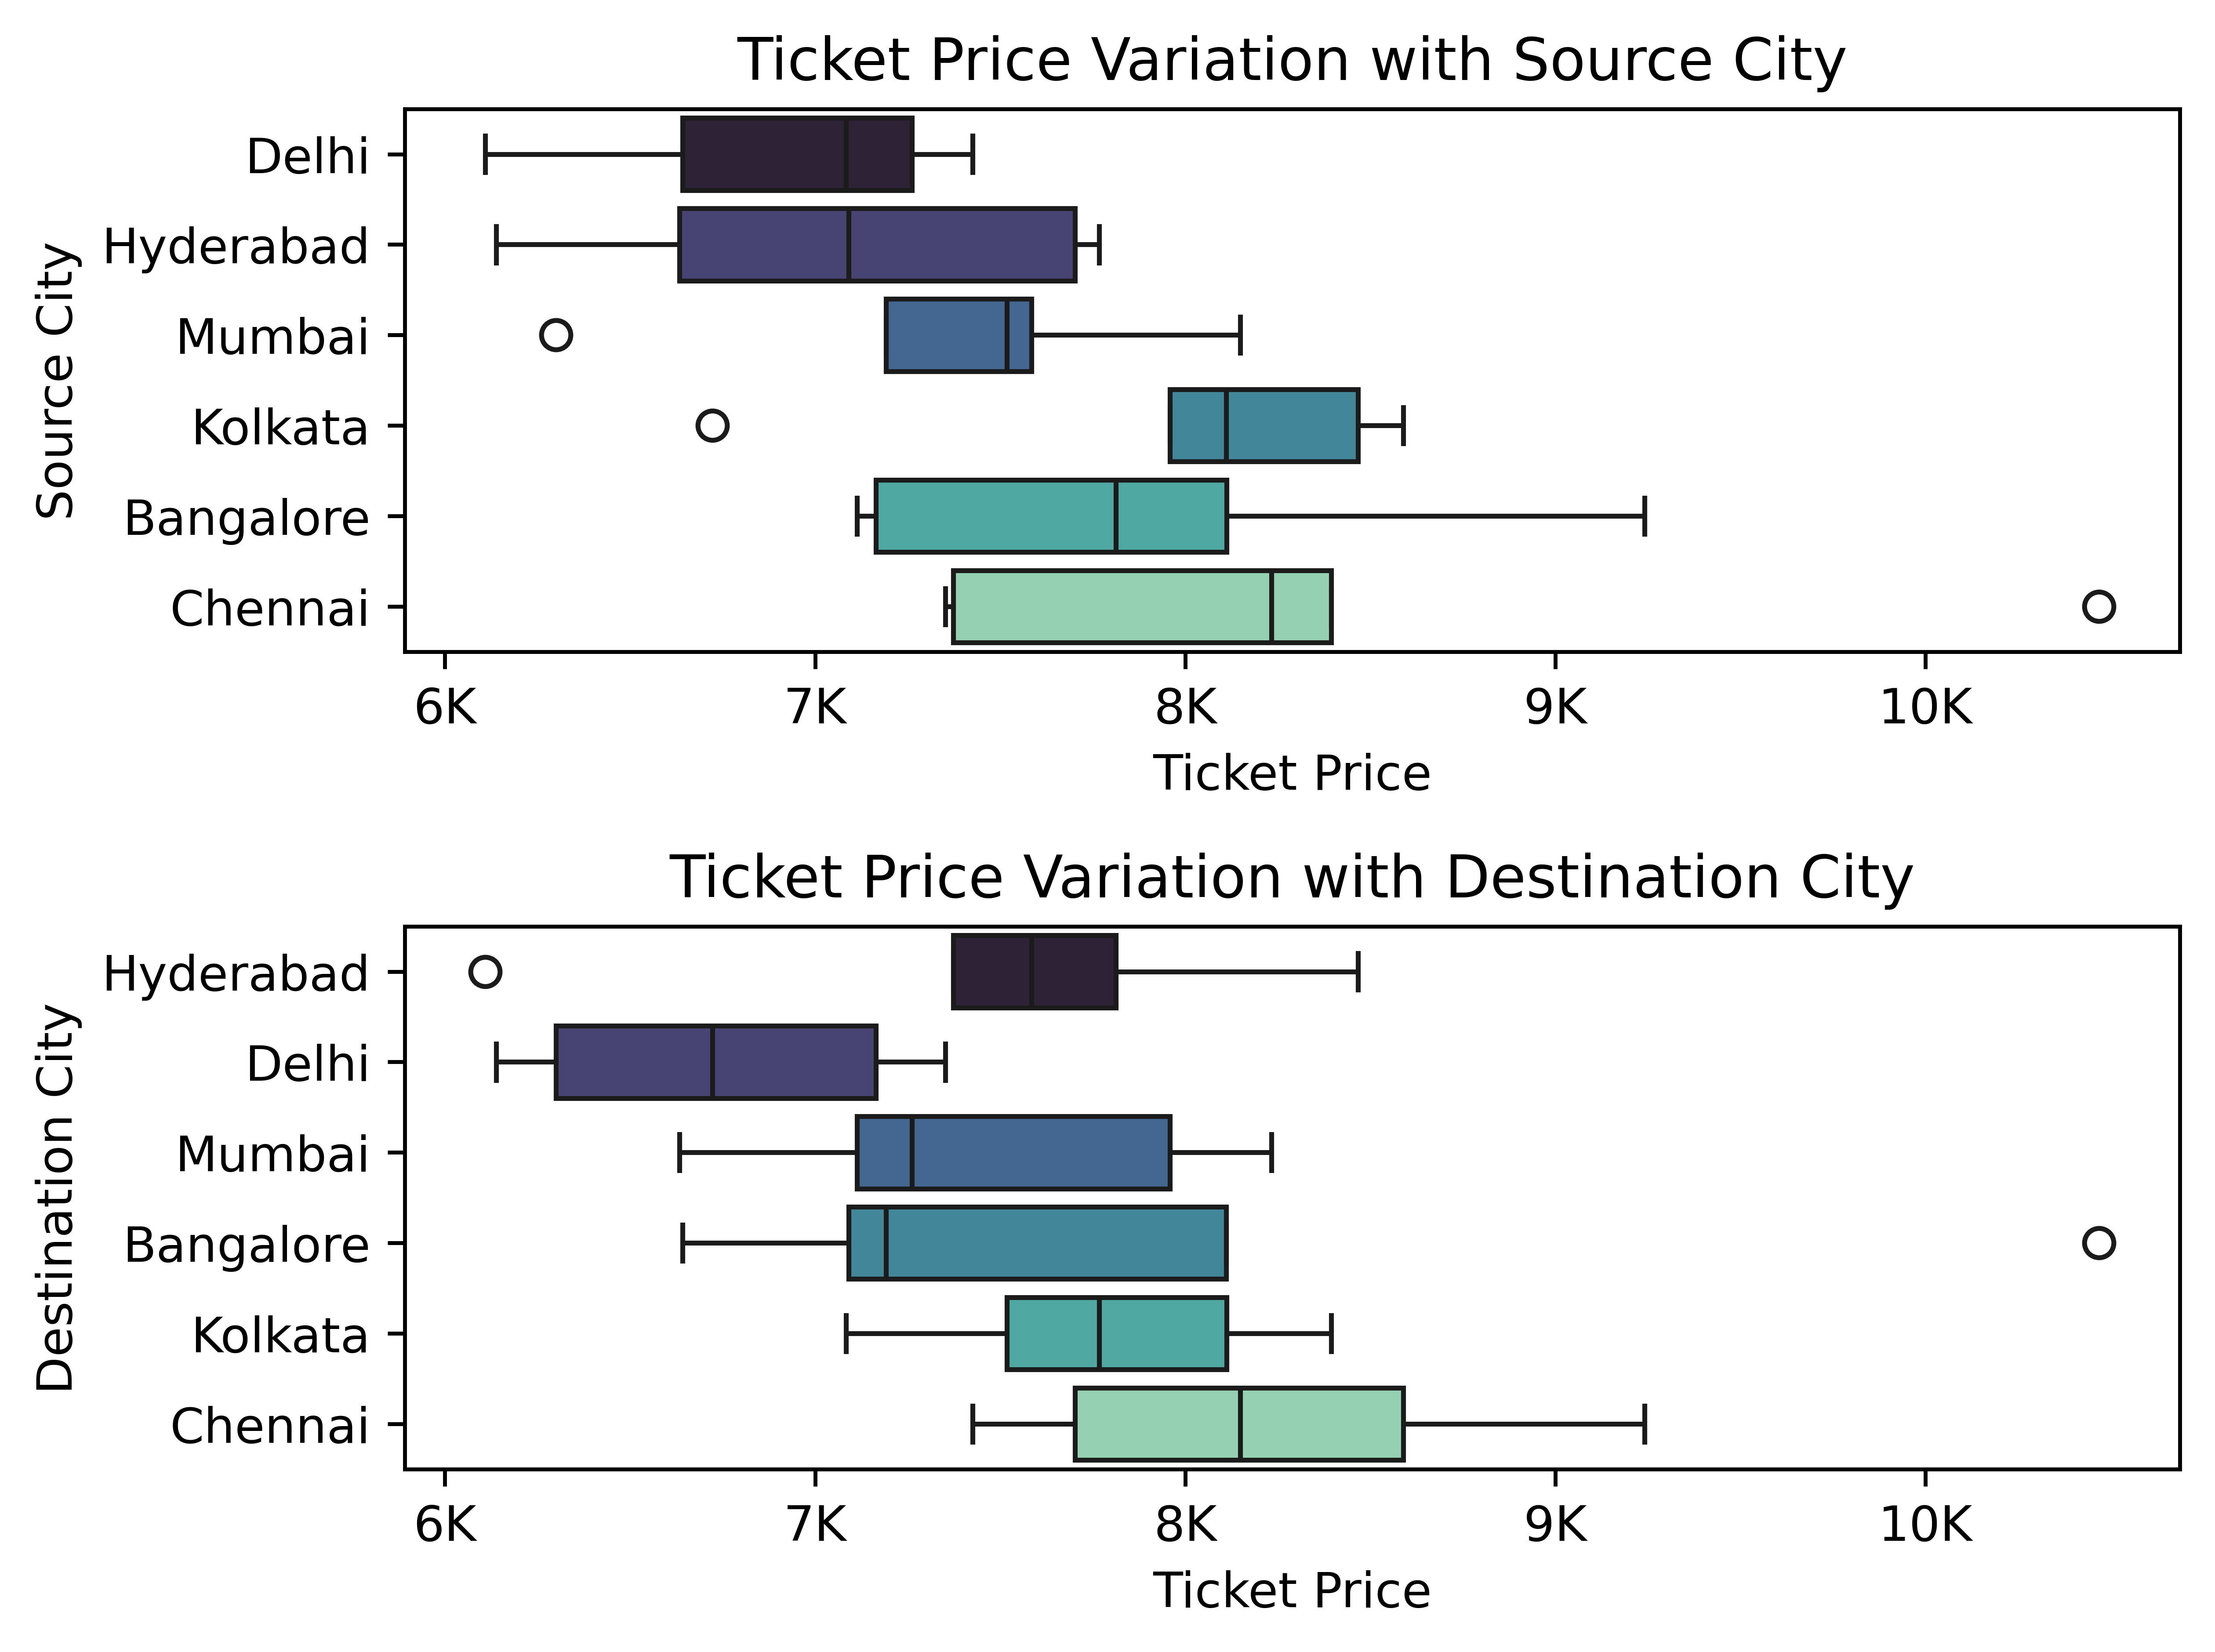

In [11]:
#Q.6. How the price changes with change in Source and Destination?
csv_plot = csv[['source_city', 'destination_city', 'price']].copy()
csv_plot = csv_plot.groupby(['source_city', 'destination_city'])['price'].median()
csv_plot = csv_plot.reset_index()
fig, ax = plt.subplots(2, 1)
ascending_order = csv_plot[['source_city', 'price']].sort_values(by='price', ascending=True)
ascending_order = ascending_order['source_city'].unique()
sns.boxplot(data=csv_plot, x='price', y='source_city', order=ascending_order, palette='mako', ax=ax[0])
ascending_order = csv_plot[['destination_city', 'price']].sort_values(by='price', ascending=True)
ascending_order = ascending_order['destination_city'].unique()
sns.boxplot(data=csv_plot, x='price', y='destination_city', order=ascending_order, palette='mako', ax=ax[1])
ax[0].set_title('Ticket Price Variation with Source City')
ax[0].set_xlabel('Ticket Price')
ax[0].set_ylabel('Source City')
ax[1].set_title('Ticket Price Variation with Destination City')
ax[1].set_xlabel('Ticket Price')
ax[1].set_ylabel('Destination City')
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[0].figure.set_dpi(800)
ax[1].figure.set_dpi(800)
plt.tight_layout()
plt.show()

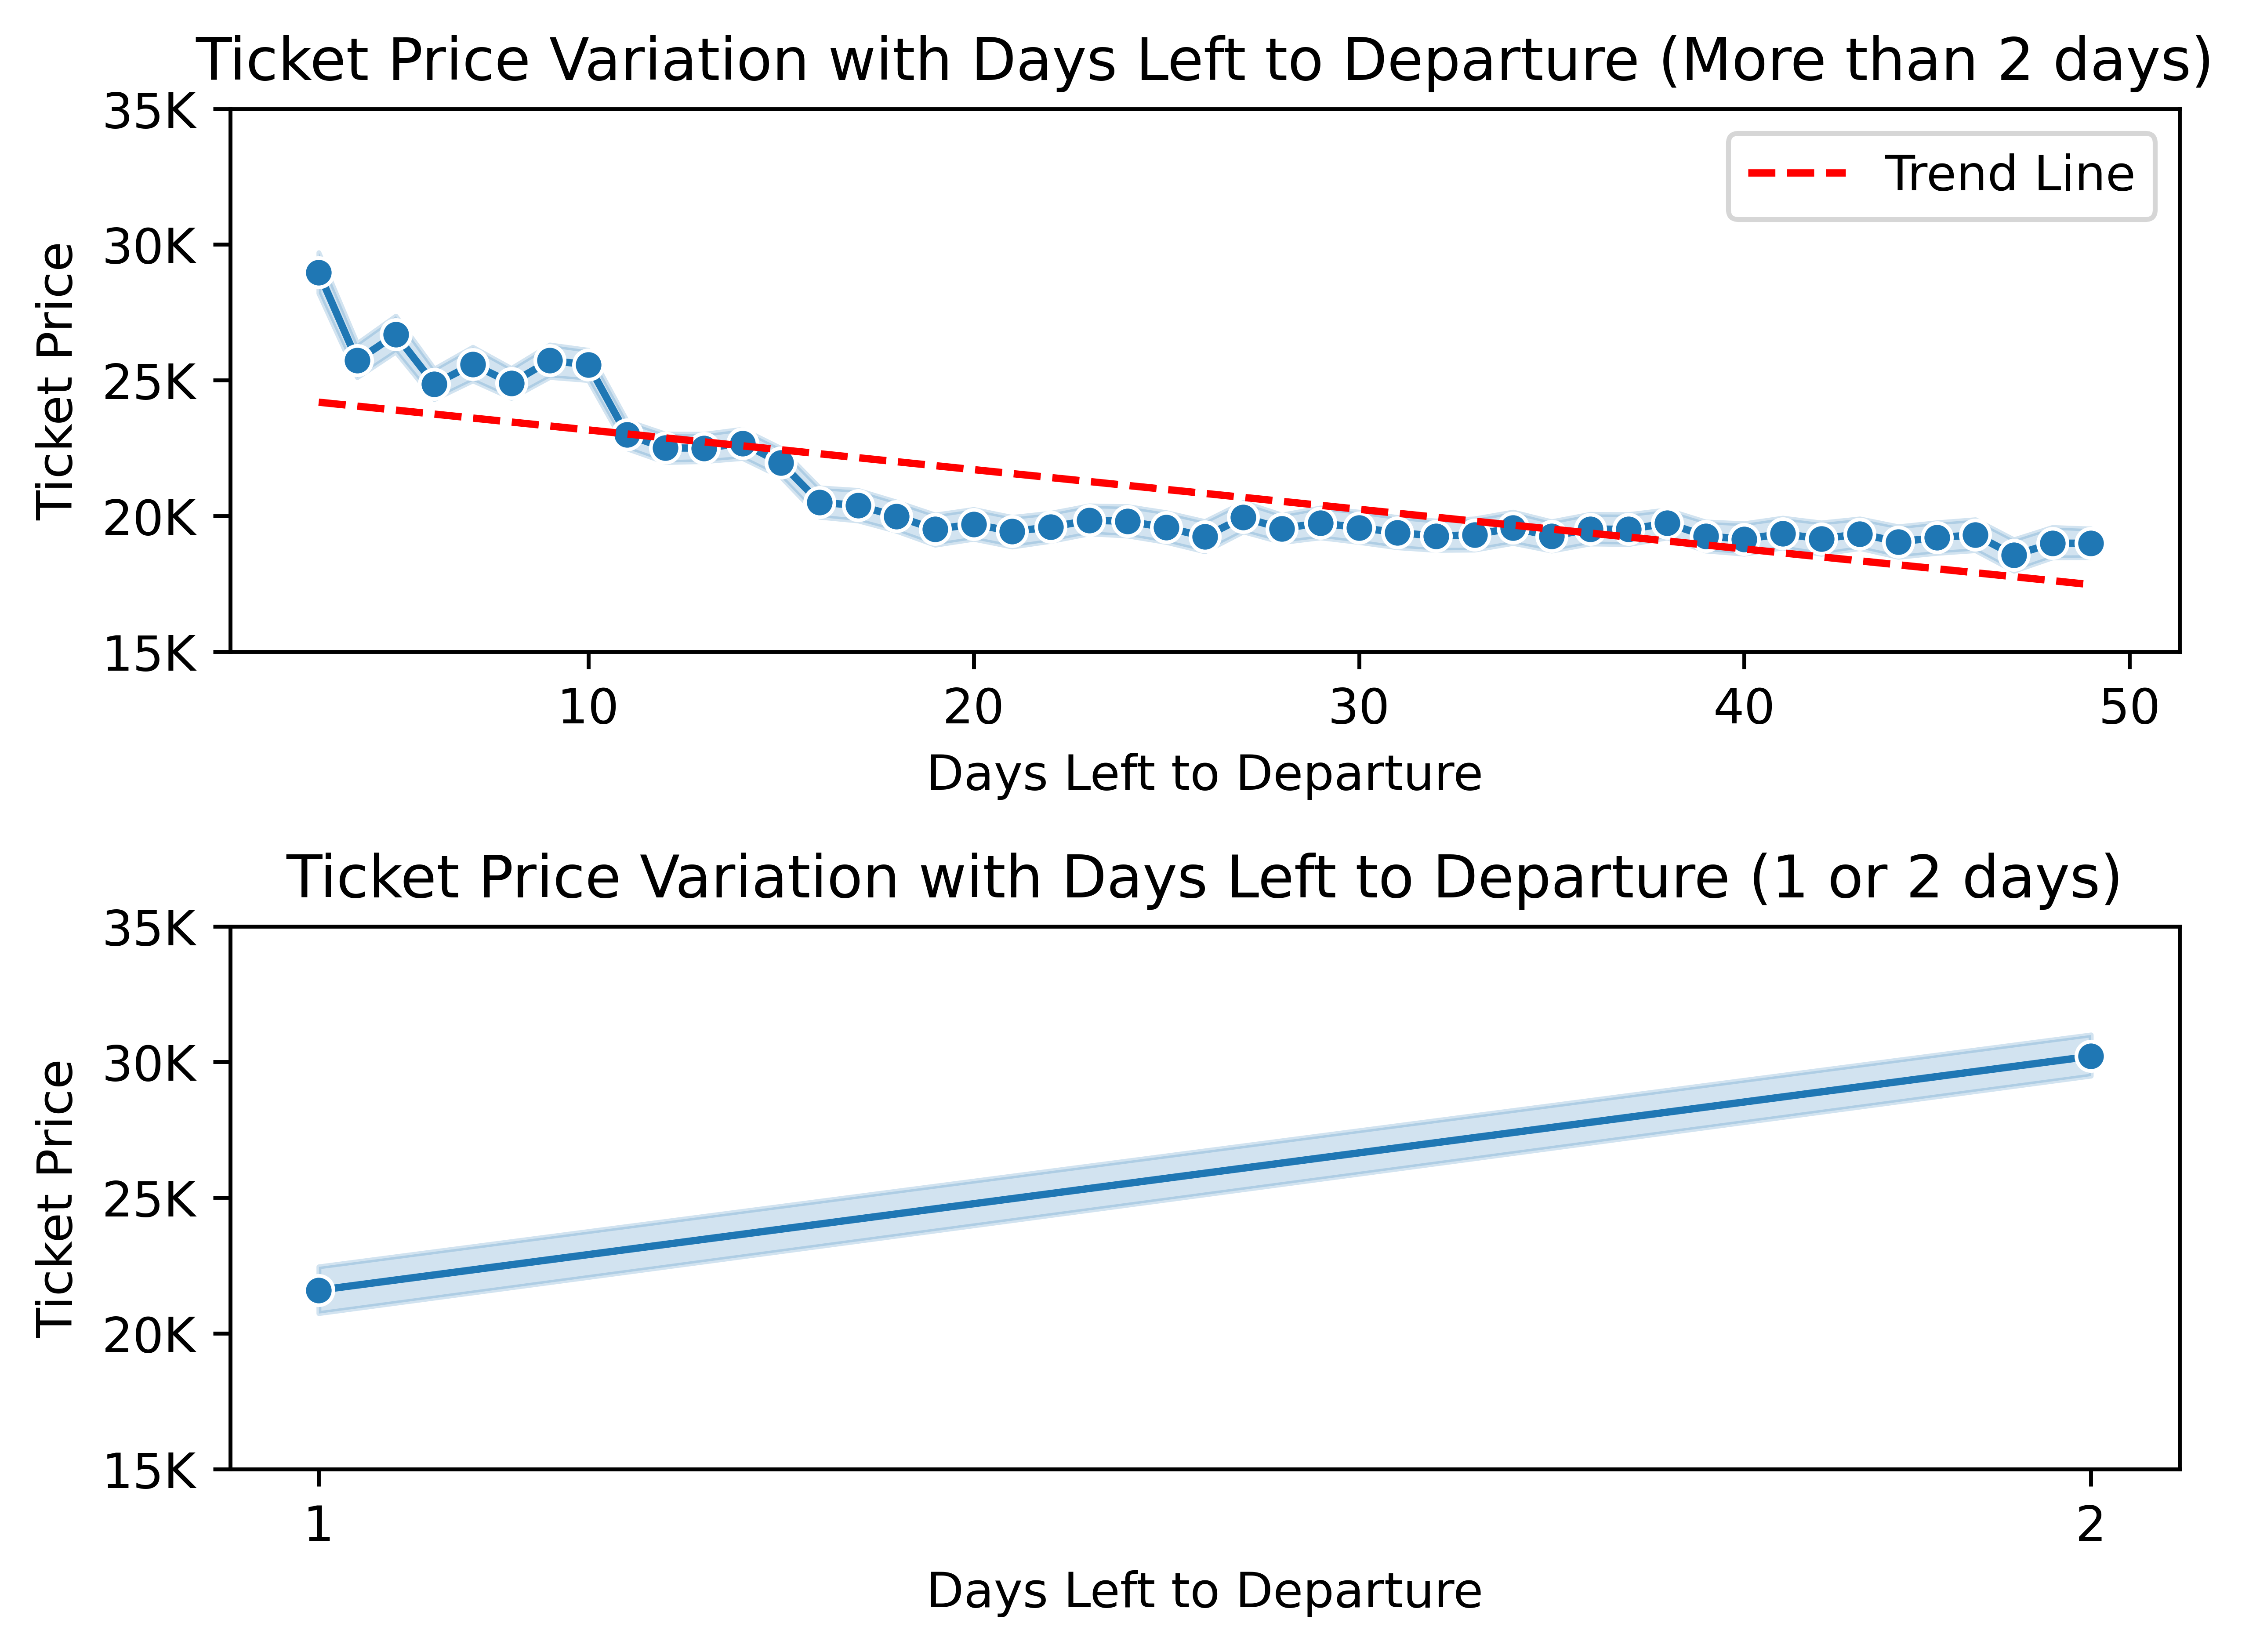

In [12]:
#Q.7. How is the price affected when tickets are bought in just 1 or 2 days before departure?
csv_plot = csv[['days_left', 'price']].copy()
fig, ax = plt.subplots(2, 1)
sns.lineplot(data=csv_plot[csv_plot['days_left']>2], x='days_left', y='price', ax=ax[0], marker='o')

# Add trend line
subset = csv_plot[csv_plot['days_left']>2]
z = np.polyfit(subset['days_left'], subset['price'], 1)
p = np.poly1d(z)
ax[0].plot(subset['days_left'], p(subset['days_left']), color='red', linestyle='--', label='Trend Line')
ax[0].legend()

sns.lineplot(data=csv_plot[csv_plot['days_left']<=2], x='days_left', y='price', ax=ax[1], marker='o')
ax[0].set_title('Ticket Price Variation with Days Left to Departure (More than 2 days)')
ax[0].set_xlabel('Days Left to Departure')
ax[0].set_ylabel('Ticket Price')
ax[1].set_title('Ticket Price Variation with Days Left to Departure (1 or 2 days)')
ax[1].set_xlabel('Days Left to Departure')
ax[1].set_ylabel('Ticket Price')
ax[1].set_xticks([1, 2])
ax[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
ax[0].figure.set_dpi(800)
ax[1].figure.set_dpi(800)
ax[0].set_ylim(15000, 35000)
ax[1].set_ylim(15000, 35000)

plt.tight_layout()
plt.show()

/var/folders/s_/ggnpv55n1fg1ylmddwvfk_bc0000gn/T/ipykernel_4444/2430401894.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=csv_plot, x='price', y='class', order=csv_plot['class'].value_counts().index, palette='crest', errorbar=None, hue=None)


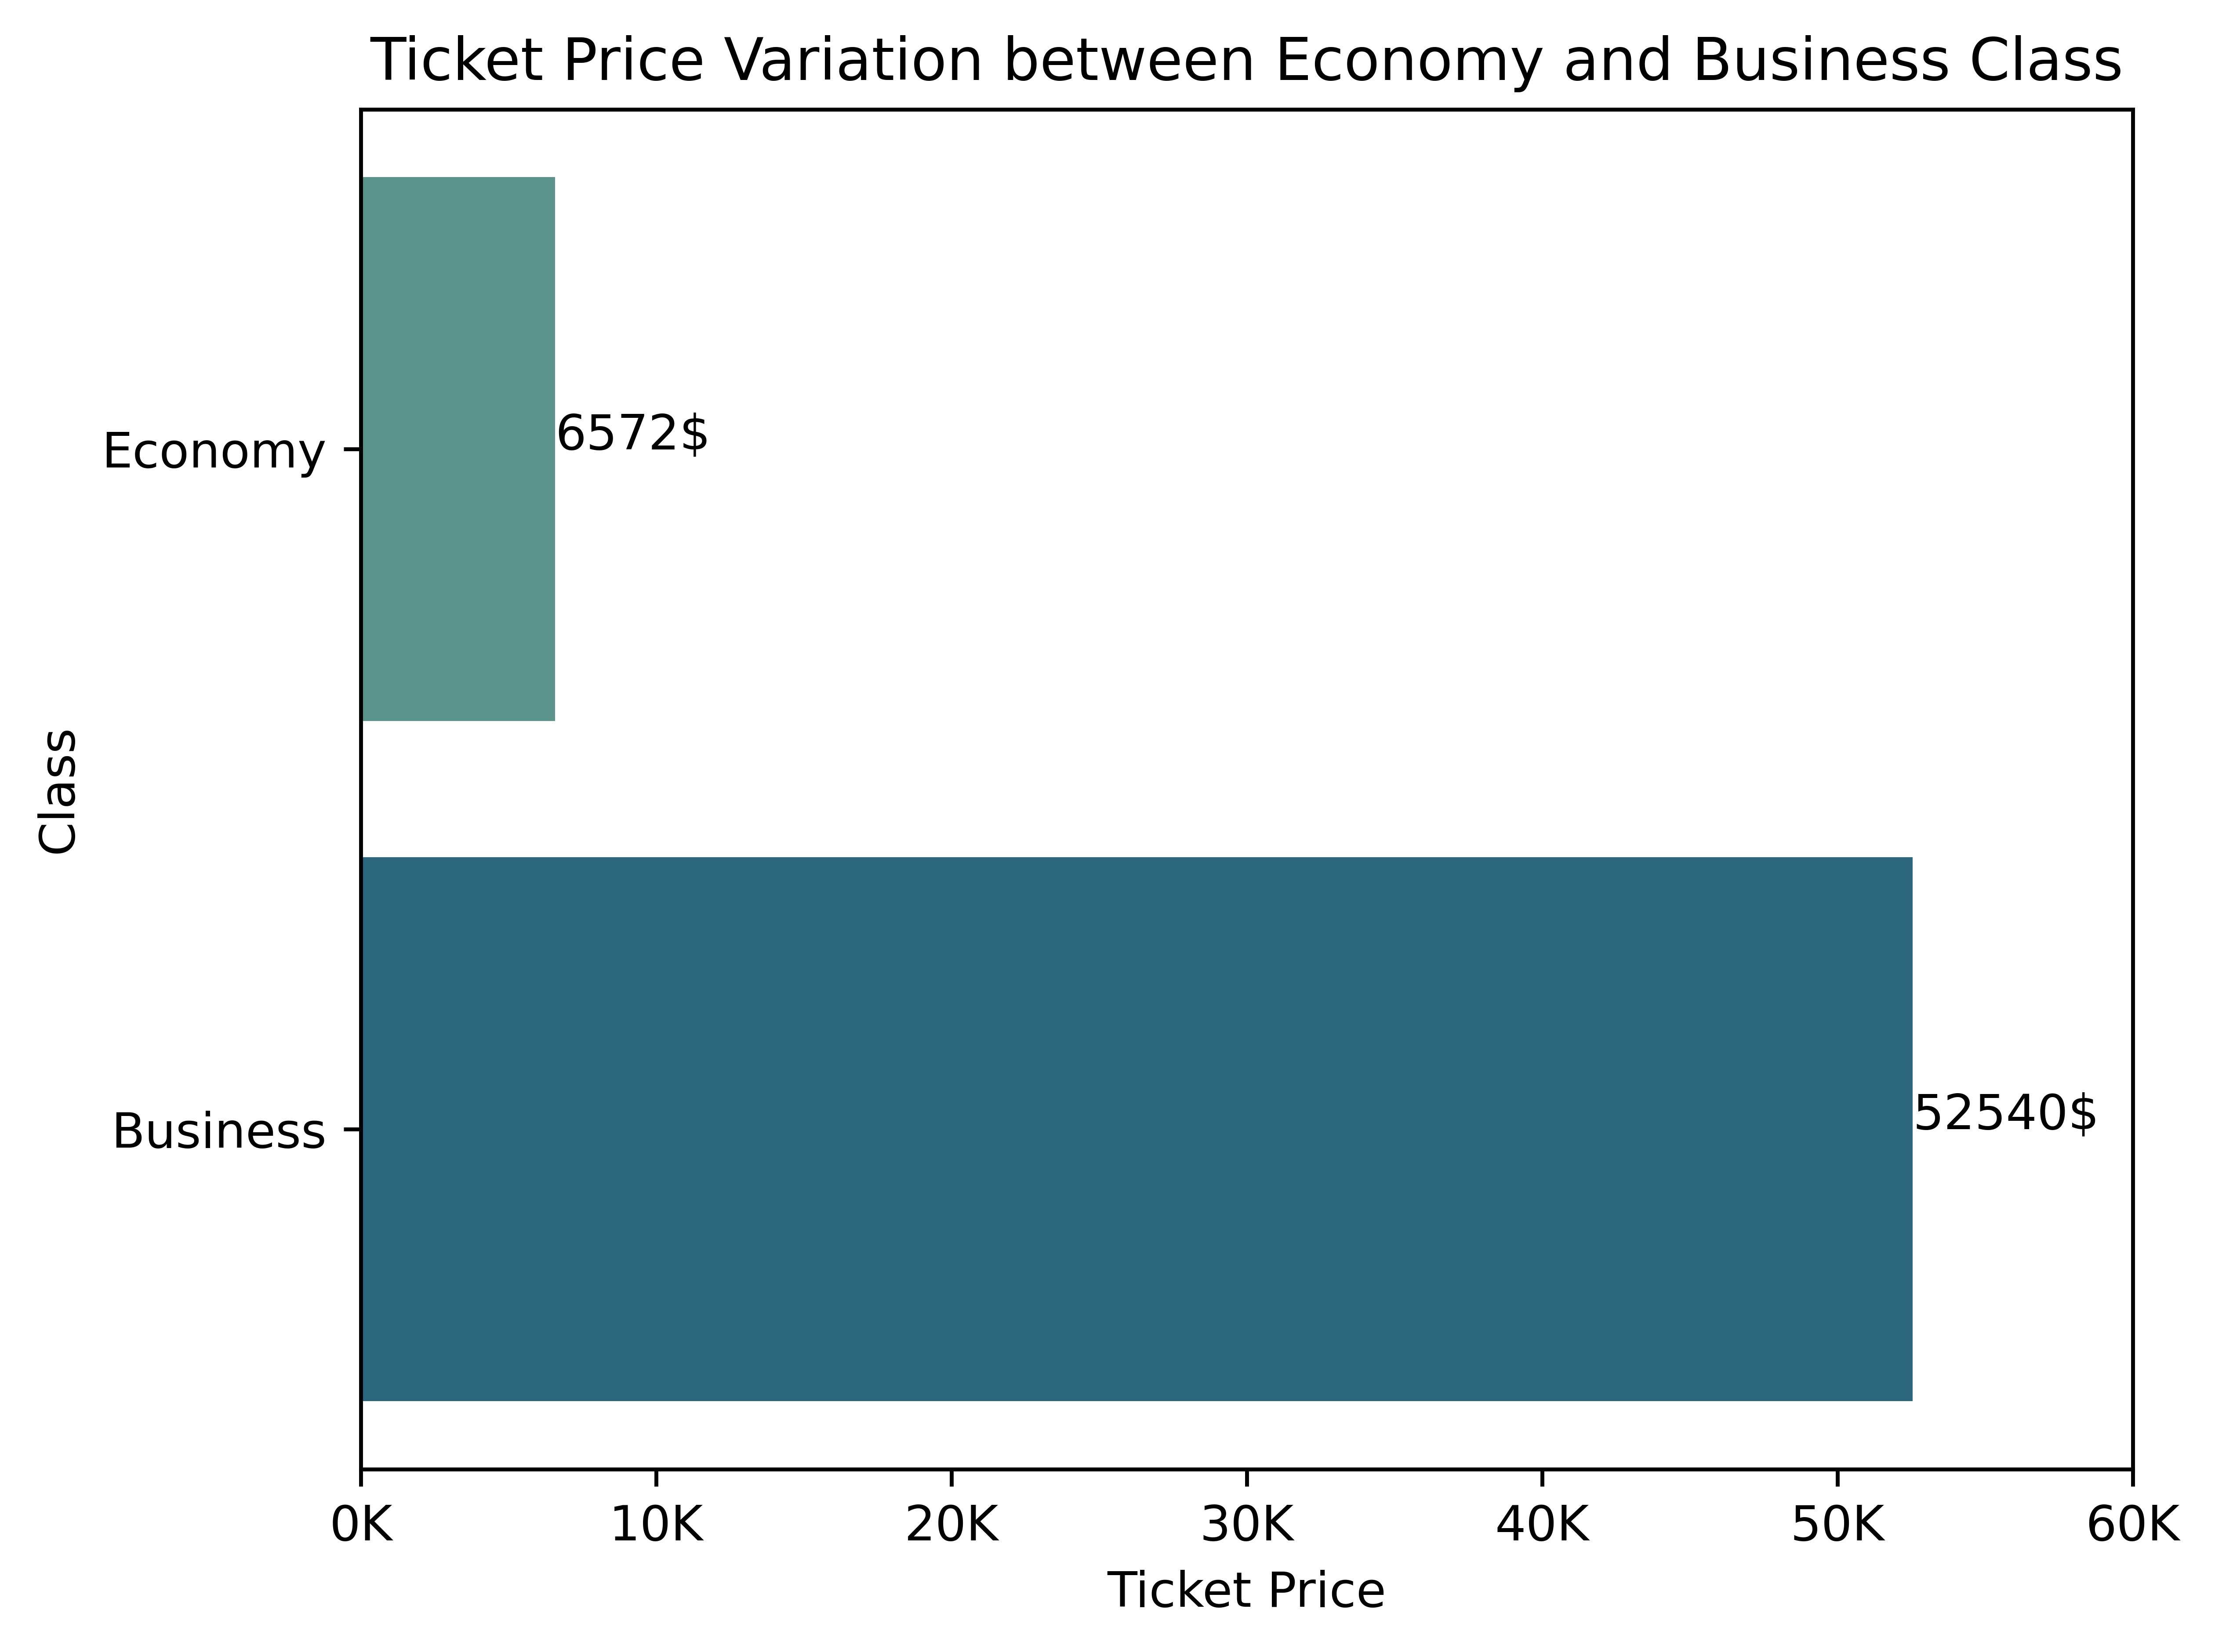

In [13]:
#Q.8. How does the ticket price vary between Economy and Business class?
csv_plot = csv[['class', 'price']].copy()
sns.barplot(data=csv_plot, x='price', y='class', order=csv_plot['class'].value_counts().index, palette='crest', errorbar=None, hue=None)
economy_mean = csv_plot[csv_plot['class'] == 'Economy']["price"].mean()
business_mean = csv_plot[csv_plot['class'] == 'Business']["price"].mean()
plt.text(economy_mean+10, 0, str(int(economy_mean))+'$', fontsize=10, color='black')
plt.text(business_mean+10, 1, str(int(business_mean))+'$', fontsize=10, color='black')
plt.xlim(0, 60000)
plt.title('Ticket Price Variation between Economy and Business Class')
plt.xlabel('Ticket Price')
plt.ylabel('Class')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
plt.gca().figure.set_dpi(800)
plt.tight_layout()
plt.show()

In [14]:
#Q.9. What will be the Average Price of Vistara airline for a flight from Delhi to Hyderabad in Business Class ?
csv[(csv['airline'] == 'Vistara') & (csv['source_city'] == 'Delhi') 
    & (csv['destination_city'] == 'Hyderabad') & (csv['class'] == 'Business')]['price'].median()
# I prefer median over mean because of the outliers in the dataset

51697.0